In [14]:
import json
import random
import time
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay,
                             roc_curve, RocCurveDisplay, auc,
                             precision_recall_curve, PrecisionRecallDisplay)

class TMPNetwork(nn.Module):
    def __init__(self, node_feature_dim, edge_type_count, hidden_dim, output_dim=1, edge_embedding_dim=16):
        """
        Initializes the TMP Network layers.

        Args:
            node_feature_dim (int): Dimension of the input node features (h^0).
            edge_type_count (int): Number of unique edge types.
            hidden_dim (int): Dimension of the hidden states (h_k).
            output_dim (int): Dimension of the final output (usually 1 for binary classification).
            edge_embedding_dim (int): Dimension to embed edge types into.
        """
        super(TMPNetwork, self).__init__()
        self.hidden_dim = hidden_dim

        # Layer for projecting initial node features if needed
        self.initial_projection = None
        if node_feature_dim != hidden_dim:
             self.initial_projection = nn.Linear(node_feature_dim, hidden_dim)

        # MessagePropogation
        self.edge_type_embedding = nn.Embedding(edge_type_count, edge_embedding_dim)
        self.Wk_layer = nn.Linear(hidden_dim + edge_embedding_dim, hidden_dim)
        self.U_layer = nn.Linear(hidden_dim, hidden_dim)
        self.Z_layer = nn.Linear(hidden_dim, hidden_dim)

        # Readoutphase
        readout_input_dim = 2 * hidden_dim
        self.Wg1_layer = nn.Linear(readout_input_dim, hidden_dim)
        self.Wg2_layer = nn.Linear(hidden_dim, hidden_dim)
        self.Wo1_layer = nn.Linear(readout_input_dim, hidden_dim)
        self.Wo2_layer = nn.Linear(hidden_dim, hidden_dim)
        self.final_layer = nn.Linear(hidden_dim, output_dim)

        # Activation functions
        self.tanh = nn.Tanh()
        self.softmax = nn.Softmax(dim=-1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, node_features, edges):
        """
        Performs the forward pass through the TMP network.

        Args:
            node_features (torch.Tensor): Tensor of initial node features (h^0).
                                         Shape: (num_nodes, node_feature_dim)
            edges (list): List of edges, where each edge is [start_idx, end_idx, type_idx].
                          NOTE: The JSON uses [start_idx, type_idx, end_idx].
                          This function expects the format [start_idx, end_idx, type_idx].

        Returns:
            torch.Tensor: Final prediction score (probability). Shape: (1,)
        """
        num_nodes = node_features.shape[0]
        if num_nodes == 0:
             return torch.tensor([0.5], dtype=torch.float32, device=node_features.device)


      
        if self.initial_projection:
             h_current = self.tanh(self.initial_projection(node_features))
        else:
             
             # Using tanh like the projection case for consistency.
             h_current = self.tanh(node_features) 

        h_0 = h_current.clone() # Keep initial states for readout

        # Message Propogation
        for k, edge in enumerate(edges):
            start_idx, end_idx, type_idx = edge

            # Trying to do index validation
            if not (0 <= start_idx < num_nodes and 0 <= end_idx < num_nodes):
                 #Trying to do some error handleing
                 raise IndexError(f"Edge index out of bounds: edge=({start_idx}, {end_idx}, {type_idx}), num_nodes={num_nodes}")


            h_sk = h_current[start_idx]
            edge_type_tensor = torch.tensor([type_idx], dtype=torch.long, device=h_current.device)
            t_k = self.edge_type_embedding(edge_type_tensor).squeeze(0)

            x_k = torch.cat((h_sk, t_k))
            m_k = self.Wk_layer(x_k) # Wk*xk + bk

            h_ek_prev = h_current[end_idx]
            h_hat_ek = self.tanh(self.U_layer(m_k) + self.Z_layer(h_ek_prev))

            # Update using clone and assign - safer, though slightly less efficient
            with torch.no_grad():
                 h_new = h_current.clone()
                 h_new[end_idx] = h_hat_ek
                 h_current = h_new

        # Readout
        h_T = h_current
        s = torch.cat((h_T, h_0), dim=1)

        g_inner = self.tanh(self.Wg1_layer(s))
        g = self.softmax(self.Wg2_layer(g_inner))

        o_inner = self.tanh(self.Wo1_layer(s))
        o = self.softmax(self.Wo2_layer(o_inner))

        gated_output = o * g
        aggregated_output = torch.sum(gated_output, dim=0)

        logit = self.final_layer(aggregated_output)
        prediction = self.sigmoid(logit)

        return prediction


In [10]:
def load_and_process_data(filepath):
    try:
        with open(filepath, 'r') as f:
            raw_data = json.load(f)
    except FileNotFoundError:
        print(f"Error: File not found at {filepath}")
        return None
    except json.JSONDecodeError:
        print(f"Error: Could not decode JSON from {filepath}")
        return None

    processed_data = []
    skipped_count = 0
    for i, graph_data in enumerate(raw_data):
        contract_name = graph_data.get('contract_name', f'Unknown_{i}')

        #Target
        try:
            target = float(graph_data['targets'])
            target_tensor = torch.tensor([target], dtype=torch.float32)
        except (KeyError, ValueError, TypeError) as e:
            print(f"Warning: Skipping graph for {contract_name}. Invalid target: {graph_data.get('targets')}. Error: {e}")
            skipped_count += 1
            continue

        # Node Features
        if not graph_data.get('node_features') or not isinstance(graph_data['node_features'], list):
            print(f"Warning: Skipping graph for {contract_name}. Missing or invalid 'node_features'.")
            skipped_count += 1
            continue
        
        if not graph_data['node_features'] or not all(isinstance(nf, list) for nf in graph_data['node_features']):
             if len(graph_data['node_features']) == 1 and not graph_data['node_features'][0]:
                 print(f"Warning: Skipping graph for {contract_name}. 'node_features' contains only an empty list.")
             else:
                 print(f"Warning: Skipping graph for {contract_name}. Invalid format inside 'node_features'.")
             skipped_count += 1
             continue
        try:
             node_features_np = np.array(graph_data['node_features'], dtype=np.float32)
             if node_features_np.ndim != 2:
                 raise ValueError("Node features not 2D array")
             node_features_tensor = torch.tensor(node_features_np)
             num_nodes = node_features_tensor.shape[0]
        except (ValueError, TypeError) as e:
            print(f"Warning: Skipping graph for {contract_name}. Error processing node features: {e}")
            skipped_count += 1
            continue

        # Edges
        # Graoh data might be missing, error handling just in case
        if not graph_data.get('graph') or not isinstance(graph_data['graph'], list):
            print(f"Warning: Graph for {contract_name} has missing or invalid 'graph' field. Treating as graph with 0 edges.")
            edges_raw = []
        else:
            edges_raw = graph_data['graph']

        edges_processed = []
        valid_edges_format = True
        for edge in edges_raw:
            if isinstance(edge, list) and len(edge) == 3:
                start, type_idx, end = edge
                # Validate types and indices (basic check, more thorough in forward pass)
                if not all(isinstance(i, int) for i in [start, type_idx, end]) or start < 0 or end < 0 or type_idx < 0:
                     print(f"Warning: Invalid edge data {edge} in {contract_name}. Skipping this edge.")
                     continue # Skip this edge, but keep the graph
                # Convert [start, type, end] (JSON) to [start, end, type] (Model Input)
                edges_processed.append([start, end, type_idx])
            else:
                print(f"Warning: Malformed edge {edge} in {contract_name}. Skipping this edge.")
                

      

        # Add processed data
        processed_data.append({
            'contract_name': contract_name,
            'node_features': node_features_tensor,
            'edges': edges_processed,
            'target': target_tensor,
            'num_nodes': num_nodes # Store num_nodes for easier checking later
        })

    print(f"Finished processing {filepath}. Loaded {len(processed_data)} graphs. Skipped {skipped_count} graphs due to errors.")
    return processed_data

    


In [11]:

print("Loading training data...")
train_data = load_and_process_data('/teamspace/studios/this_studio/GNNSCVulDetectorGit/train_data/reentrancy/train.json')
print("\nLoading validation data...")
valid_data = load_and_process_data('GNNSCVulDetectorGit/train_data/reentrancy/valid.json')

if not train_data:
    print("Error: Could not load or process training data. Exiting.")
    exit()
if not valid_data:
     print("Warning: Could not load or process validation data. Evaluation will be skipped.")
     exit()


# determine model dimensions from training data 
if not train_data[0]['node_features'].numel() > 0 : # Check if the first graph has any node features
     print("Error: First graph in training data has no node features. Cannot determine dimension.")
     #
     NODE_FEATURE_DIM = -1 # Indicate error
     for data in train_data:
         if data['node_features'].numel() > 0:
              NODE_FEATURE_DIM = data['node_features'].shape[1]
              print(f"Determined NODE_FEATURE_DIM from later graph: {NODE_FEATURE_DIM}")
              break
     if NODE_FEATURE_DIM == -1:
          print("Error: Could not find any graph with node features in training data. Exiting.")
          exit()
else:
    NODE_FEATURE_DIM = train_data[0]['node_features'].shape[1]


max_edge_type_idx = -1
for graph_data in train_data:
    if graph_data['edges']: # checking if graph has edges
      try:
        # edges now [start, end, type_idx]
        current_max = max(edge[2] for edge in graph_data['edges'])
        if current_max > max_edge_type_idx:
            max_edge_type_idx = current_max
      except ValueError: # case handling where edges might be empty after filtering bad ones
          pass
      except IndexError as e:
          print(f"Warning: IndexError processing edges in training graph for {graph_data['contract_name']}: {e}")


if max_edge_type_idx == -1:
     print("Warning: Could not determine maximum edge type index from training data. Setting EDGE_TYPE_COUNT to 1 (only index 0).")
     EDGE_TYPE_COUNT = 1 # Only edge type 0 exists or no edges found
else:
     EDGE_TYPE_COUNT = max_edge_type_idx + 1 # Indices are 0 to max_idx

print(f"\nDetermined from Training Data:")
print(f"NODE_FEATURE_DIM: {NODE_FEATURE_DIM}")
print(f"EDGE_TYPE_COUNT: {EDGE_TYPE_COUNT} (Max Index Found: {max_edge_type_idx})")

Loading training data...
Finished processing /teamspace/studios/this_studio/GNNSCVulDetectorGit/train_data/reentrancy/train.json. Loaded 4948 graphs. Skipped 0 graphs due to errors.

Loading validation data...
Finished processing GNNSCVulDetectorGit/train_data/reentrancy/valid.json. Loaded 1252 graphs. Skipped 0 graphs due to errors.

Determined from Training Data:
NODE_FEATURE_DIM: 250
EDGE_TYPE_COUNT: 12 (Max Index Found: 11)



Using device: cpu

--- Starting Training Loop ---
Training data loaded: 4948 graphs
Validation data loaded: 1252 graphs
Epochs to run: 100
Using device: cpu
Epoch 1/100 Completed | Time: 19.21s | Train Loss: 0.3819 | Val Loss: 0.2939 | Val Acc: 0.8810
Epoch 2/100 Completed | Time: 20.37s | Train Loss: 0.2910 | Val Loss: 0.2636 | Val Acc: 0.8778
Epoch 3/100 Completed | Time: 18.46s | Train Loss: 0.2725 | Val Loss: 0.2503 | Val Acc: 0.9097
Epoch 4/100 Completed | Time: 20.37s | Train Loss: 0.2072 | Val Loss: 0.2010 | Val Acc: 0.9161
Epoch 5/100 Completed | Time: 17.73s | Train Loss: 0.1736 | Val Loss: 0.1823 | Val Acc: 0.9257
Epoch 6/100 Completed | Time: 18.45s | Train Loss: 0.1573 | Val Loss: 0.1539 | Val Acc: 0.9321
Epoch 7/100 Completed | Time: 17.49s | Train Loss: 0.1470 | Val Loss: 0.1512 | Val Acc: 0.9289
Epoch 8/100 Completed | Time: 19.26s | Train Loss: 0.1346 | Val Loss: 0.1746 | Val Acc: 0.9097
Epoch 9/100 Completed | Time: 17.76s | Train Loss: 0.1306 | Val Loss: 0.1345 | Val

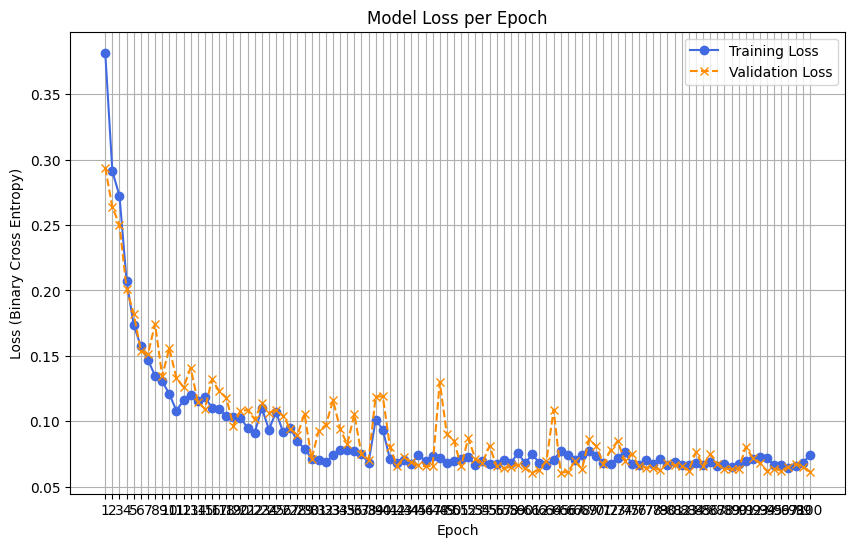

In [18]:
import matplotlib.pyplot as plt


HIDDEN_DIM = 64
EDGE_EMBEDDING_DIM = 32
OUTPUT_DIM = 1
LEARNING_RATE = 0.001
EPOCHS = 100 
BATCH_SIZE = 1 # processing one graph at a time


model = TMPNetwork(
    node_feature_dim=NODE_FEATURE_DIM,
    edge_type_count=EDGE_TYPE_COUNT, # Ensure this is >= 1
    hidden_dim=HIDDEN_DIM,
    edge_embedding_dim=EDGE_EMBEDDING_DIM,
    output_dim=OUTPUT_DIM
)

optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
criterion = nn.BCELoss() # Binary Cross Entropy Loss

# device config as we were using a cloud CPU to train this model
device = torch.device('cpu') # force CPU here
model.to(device)
print(f"\nUsing device: {device}")


train_losses = [] # store average training loss per epoch
val_losses = []   # store average validation loss per epoch

print("\n--- Starting Training Loop ---")
if not train_data:
     print("Error: No training data loaded. Cannot start training.")
     
else:
     print(f"Training data loaded: {len(train_data)} graphs")

if not valid_data:
     print("Warning: No validation data loaded. Validation loss will not be tracked or plotted.")
else:
     print(f"Validation data loaded: {len(valid_data)} graphs")

print(f"Epochs to run: {EPOCHS}")
print(f"Using device: {device}")


#Training
for epoch in range(EPOCHS):
    model.train() 
    total_train_loss = 0.0
    graphs_processed_in_epoch = 0
    start_time = time.time()

    # shuffle training data each epoch
    if train_data: # Error handling again: only shuffle if data exists
         random.shuffle(train_data)

         for i, graph_data in enumerate(train_data):
             # Get data for the current graph
             node_features = graph_data['node_features'].to(device)
             target = graph_data['target'].to(device)
             edges = graph_data['edges']
             num_nodes = graph_data['num_nodes']

             # Skip empty graphs
             if num_nodes == 0:
                 continue

             # main training step backpropogation etc.
             optimizer.zero_grad()
             try:
                 output = model(node_features, edges)
                 loss = criterion(output, target)
                 loss.backward()
                 optimizer.step()
                 total_train_loss += loss.item()
                 graphs_processed_in_epoch += 1
             except Exception as e: # Catch potential errors during training step
                  print(f"\nWarning: Error processing graph {graph_data.get('contract_name', 'N/A')} during training in epoch {epoch+1}: {e}. Skipping graph.")

    # calc average training loss for epoch
    if graphs_processed_in_epoch > 0:
        avg_train_loss = total_train_loss / graphs_processed_in_epoch
        train_losses.append(avg_train_loss)
    else:
        # Handle case where no graphs could be processed (e.g., all were skipped)
        avg_train_loss = float('nan')
        train_losses.append(avg_train_loss)

    # Validation phase
    avg_val_loss = float('nan') # default validation loss set to NaN
    val_acc_epoch = float('nan') # accuracy to NaN
    if valid_data: 
        
    
        try:
             # Set model to eval mode for validation
             
             val_results = evaluate_model(model, valid_data, criterion, device)
             avg_val_loss = val_results[0] # first returned value is  avg loss
             val_acc_epoch = val_results[1] # Second is accuracy
             val_losses.append(avg_val_loss) #validation loss
        except Exception as e:
             print(f"\nWarning: Error during validation in epoch {epoch+1}: {e}. Storing NaN for validation loss.")
             val_losses.append(float('nan')) # Store NaN if eval function fails
    else:
        # append NaN to keep list lengths consistent
        val_losses.append(float('nan'))


    # epoch summary
    epoch_duration = time.time() - start_time
    print(f"Epoch {epoch+1}/{EPOCHS} Completed | "
          f"Time: {epoch_duration:.2f}s | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"Val Acc: {val_acc_epoch:.4f}")


print("\n--- Generating Training/Validation Loss Plot ---")

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 6)) 



if any(not np.isnan(loss) for loss in train_losses):
    plt.plot(epochs_range, train_losses, label='Training Loss', marker='o', linestyle='-', color='royalblue')
else:
    print("Note: No valid training loss points to plot.")




if valid_data and any(not np.isnan(loss) for loss in val_losses):
    plt.plot(epochs_range, val_losses, label='Validation Loss', marker='x', linestyle='--', color='darkorange')
elif not valid_data:
    print("Note: Validation loss not plotted as no validation data was provided.")
else: # valid_data existed, but results were NaN
     print("Note: Validation loss not plotted as results were NaN.")



plt.title('Model Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss (Binary Cross Entropy)')
plt.xticks(epochs_range) 
plt.grid(True) 


if valid_data and any(not np.isnan(loss) for loss in train_losses) and any(not np.isnan(loss) for loss in val_losses):
    plt.legend()
elif any(not np.isnan(loss) for loss in train_losses): 
     plt.legend(['Training Loss'])


plt.show() 


--- Generating Training/Validation Loss Plot ---


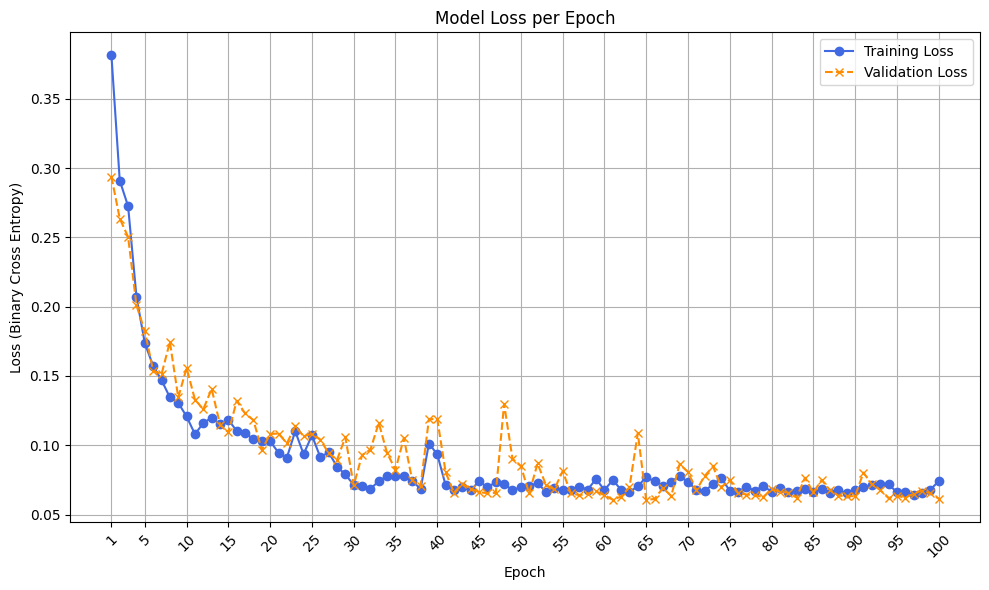

In [23]:
import matplotlib.pyplot as plt
import numpy as np


epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(10, 6))


if any(not np.isnan(loss) for loss in train_losses):
    plt.plot(epochs_range, train_losses,
             label='Training Loss',
             marker='o', linestyle='-',
             color='royalblue')
else:
    print("Note: No valid training loss points to plot.")


if valid_data and any(not np.isnan(loss) for loss in val_losses):
    plt.plot(epochs_range, val_losses,
             label='Validation Loss',
             marker='x', linestyle='--',
             color='darkorange')
elif not valid_data:
    print("Note: Validation loss not plotted as no validation data was provided.")
else:
    print("Note: Validation loss not plotted as results were NaN.")

plt.title('Model Loss per Epoch')
plt.xlabel('Epoch')
plt.ylabel('Loss (Binary Cross Entropy)')

ticks = [1] + list(range(5, EPOCHS+1,5))

plt.xticks(
    ticks=ticks,      
    labels=ticks,     
    rotation=45,
    fontsize=10
)


plt.grid(True)

if valid_data and any(not np.isnan(loss) for loss in train_losses) and any(not np.isnan(loss) for loss in val_losses):
    plt.legend()
elif any(not np.isnan(loss) for loss in train_losses):
    plt.legend(['Training Loss'])

plt.tight_layout()
plt.show()


In [ ]:
def evaluate_model(model, data_loader, criterion, device):
    model.eval() # Setting model to evaluation mode
    total_loss = 0.0
    all_preds = []
    all_targets = []
    graphs_processed = 0

    with torch.no_grad(): # sisable grad calculation
        for i, graph_data in enumerate(data_loader):
            node_features = graph_data['node_features'].to(device)
            target = graph_data['target'].to(device)
            edges = graph_data['edges']
            num_nodes = graph_data['num_nodes']

            if num_nodes == 0:
                
                 continue

            try:
                output = model(node_features, edges)
                loss = criterion(output, target)
                total_loss += loss.item()
                predicted_prob = output.item()
                predicted_label = 1 if predicted_prob >= 0.5 else 0 # Threshold at 0.5
                all_preds.append(predicted_label)
                all_targets.append(int(target.item()))
                graphs_processed += 1

            except IndexError as e:
                 print(f"\n!!! Evaluation Error (IndexError) !!!")
                 print(f"Graph: {graph_data['contract_name']}")
                 print(f"Error message: {e}")
                 print(f"Graph details: num_nodes={num_nodes}, edges={edges[:5]}...")
                 print("Skipping this graph in evaluation...")
            except Exception as e:
                print(f"\n!!! Evaluation Error (Unexpected) !!!")
                print(f"Graph: {graph_data['contract_name']}")
                print(f"Error message: {type(e).__name__}: {e}")
                print("Skipping this graph in evaluation")


    if graphs_processed == 0:
         print("No graphs were successfully processed during evaluation.")
         return float('nan'), float('nan'), float('nan'), float('nan'), float('nan'), 0


    avg_loss = total_loss / graphs_processed
    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds)
    recall = recall_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)

    return avg_loss, accuracy, precision, recall, f1, graphs_processed
# Validation set Eval
if valid_data: 
    val_loss, val_acc, val_prec, val_recall, val_f1, val_processed = evaluate_model(model, valid_data, criterion, device)
    if not np.isnan(val_loss): # Check if evaluation produced results
        print(f"Validation Graphs Processed: {val_processed}/{len(valid_data)}")
        print(f"Validation Loss: {val_loss:.4f}")
        print(f"Validation Accuracy: {val_acc:.4f}")
        print(f"Validation Precision: {val_prec:.4f}")
        print(f"Validation Recall: {val_recall:.4f}")
        print(f"Validation F1-Score: {val_f1:.4f}")
        

    





--- Evaluating on Validation Set ---
Validation Graphs Processed: 1252/1252
Validation Loss: 0.1316
Validation Accuracy: 0.9521
Validation Precision: 0.9261
Validation Recall: 0.9347
Validation F1-Score: 0.9304

--- Script Finished ---


NameError: name 'valid_data' is not defined

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, PrecisionRecallDisplay

def evaluate_model(model, data_loader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_pred_labels, all_pred_probs, all_targets = [], [], []
    
    with torch.no_grad():
        for graph_data in data_loader:
            output = model(
                graph_data['node_features'].to(device),
                graph_data['edges']
            )
            loss = criterion(output, graph_data['target'].to(device))
            
            total_loss += loss.item()
            all_pred_probs.append(output.item())
            all_pred_labels.append(1 if output.item() >= 0.5 else 0)
            all_targets.append(graph_data['target'].item())

    metrics = (
        total_loss / len(data_loader),
        accuracy_score(all_targets, all_pred_labels),
        precision_score(all_targets, all_pred_labels, zero_division=0),
        recall_score(all_targets, all_pred_labels, zero_division=0),
        f1_score(all_targets, all_pred_labels, zero_division=0),
        all_targets,
        all_pred_labels,
        all_pred_probs
    )
    return metrics

# Unified evaluation flow
print("\n--- Validation Results ---")
loss, acc, prec, rec, f1, targets, labels, probs = evaluate_model(model, valid_data, criterion, device)

print(f"Loss: {loss:.4f} | Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")

ConfusionMatrixDisplay.from_predictions(targets, labels).plot()
RocCurveDisplay.from_predictions(targets, probs).plot()
PrecisionRecallDisplay.from_predictions(targets, probs).plot()

plt.show()